# Forward-knee 200-step extension with two expected changes per model

This focused rerun matches the existing five-member, forward-knee, 200-step,
all-model ensemble-validation experiment but sets
`expected_changes_per_model=2`. Each selected model therefore proposes
`1 + Poisson(1)` feature-group changes per iteration, subject to feasibility.

In [1]:
from pathlib import Path
import copy
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "mistic" / "svmSet.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

Matplotlib is building the font cache; this may take a moment.


## Fixed experimental design

- 500 observations and 100 predictors: 10 informative, 10 redundant, and 80 noise.
- One stratified 25% blind set, withheld before every preprocessing and modeling step.
- Three inner seeds and exactly five SVM-set members.
- Fifteen percent of the outer-training rows are reserved for ensemble-level validation and excluded from all member CV splits.
- `combined_rank(weight=0.75)`, separate feature sets, and separate parameters.
- Forward search uses the 20-medoid singleton screen and a 20-feature maximum.
- Backward search uses scaled gamma during search and final full-grid retuning.
- Greedy selection returns the knee-selected subset before refinement.
- Stochastic variants start from identical deep copies of that subset. Every iteration budget uses the same seed. Both single-model proposals and joint all-model proposals are tested.
- Each sklearn unified-feature reference uses only the top `knee_feature_count`
  features according to the corresponding ensemble's unified rank.

In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.0,
    flip_y=0.03,
    shuffle=False,
    random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

MODEL_COUNTS = [5]
REFINEMENT_STEPS = [0, 10, 20, 50, 100]
SELECTION_STRATEGIES = ["forward_knee", "backward_knee"]
INNER_SEEDS = list(range(3))
BLIND_SET_SEED = 42
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
ENSEMBLE_VALIDATION_SIZE = 0.15
RANK_WEIGHT = 0.75
FORWARD_MAX_FEATURES = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")

Training rows: 375; fixed blind rows: 125


In [3]:
def parameter_grid():
    return [
        paramSet(model={"C": cost}, kernel={"gamma": gamma})
        for cost in C_VALUES for gamma in GAMMA_VALUES
    ]


def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def fit_sklearn_reference(X_train_subset, y_train, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced")),
    ])
    search = GridSearchCV(
        pipeline,
        {"svc__C": C_VALUES, "svc__gamma": GAMMA_VALUES},
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1,
        refit=True,
    )
    return search.fit(X_train_subset, y_train)


def fit_knee_ensemble(strategy, num_models, seed):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled,
        np.asarray(y_train),
        num_feature_medoids=20,
        ensemble_validation_size=ENSEMBLE_VALIDATION_SIZE,
        ensemble_validation_random_seed=50_000 + seed,
    )
    splits.classification(
        num_sets=num_models,
        validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"),
        splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    options = dict(
        parameter_grid=parameter_grid(),
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample",
        tune_models_each_step=False,
        post_find_knee=True,
    )
    if strategy == "forward_knee":
        ensemble.greedy_forward_selection(
            reduction_factor=0,
            max_features=FORWARD_MAX_FEATURES,
            **options,
        )
    else:
        ensemble.greedy_backward_selection(reduction_factor=0.1, **options)
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified_set = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([
        feature for feature in ensemble.unified_sorted_features
        if feature in unified_set
    ], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), 1 - signal_count / len(features)


def ensemble_row(ensemble, scaler, seed, strategy, num_models, steps, knee_count, update_all_models):
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    decisions = ensemble.decision_function(X_blind_scaled)
    unified = np.asarray(ensemble.unified_features, dtype=int)
    top20 = ranked_unified_features(ensemble, 20)
    signal_recall, noise_fraction = recovery(top20)
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i) for i in range(num_models)
    ])
    disagreement = np.mean([
        np.mean(member_predictions[:, i] != member_predictions[:, j])
        for i in range(num_models) for j in range(i + 1, num_models)
    ]) if num_models > 1 else 0.0
    history = getattr(ensemble, "stochastic_performance_", [])
    return {
        "seed": seed,
        "method": "MiSTIC SVM set",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(unified),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": disagreement,
        "accepted_moves": sum(row.accepted for row in history),
        **metric_row(y_blind, predictions, decisions),
    }


def reference_row(ensemble, seed, strategy, num_models, steps, knee_count, update_all_models):
    features = ranked_unified_features(ensemble, knee_count)
    signal_recall, noise_fraction = recovery(features)
    reference = fit_sklearn_reference(X_train.iloc[:, features], y_train, seed)
    return {
        "seed": seed,
        "method": "sklearn on knee-ranked unified features",
        "selection_strategy": strategy,
        "refinement_steps": steps,
        "update_all_models": update_all_models,
        "refinement_objective": "ensemble_validation" if steps else "knee_baseline",
        "num_models": num_models,
        "knee_feature_count": knee_count,
        "num_unified_features": len(features),
        "signal_recall": signal_recall,
        "noise_fraction": noise_fraction,
        "member_disagreement": 0.0,
        "accepted_moves": np.nan,
        **metric_row(
            y_blind,
            reference.predict(X_blind.iloc[:, features]),
            reference.decision_function(X_blind.iloc[:, features]),
        ),
    }

## Run the comparison

For each seed and selection direction, the two refined conditions begin from
independent copies of the same knee-selected ensemble. Refinement retunes every
proposal with the same parameter grid used by the greedy search.

In [4]:
rows = []
strategy = "forward_knee"
num_models = 5
steps = 200
update_all_models = True

for seed in INNER_SEEDS:
    scaler, base_ensemble, knee_count = fit_knee_ensemble(
        strategy, num_models, seed
    )
    candidate = copy.deepcopy(base_ensemble)
    candidate.stochastic_feature_selection(
        parameter_grid(),
        n_iterations=steps,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample",
        temperature=0.05,
        cooling_rate=0.97,
        add_probability=0.5,
        random_seed=10_000 + 100 * num_models + seed,
        update_all_models=True,
        use_ensemble_validation=True,
        expected_changes_per_model=2,
    )
    rows.append(ensemble_row(
        candidate, scaler, seed, strategy, num_models, steps,
        knee_count, update_all_models,
    ))
    rows.append(reference_row(
        candidate, seed, strategy, num_models, steps,
        knee_count, update_all_models,
    ))
    print(f"completed seed={seed}, forward_knee, models=5, steps=200, update_all_models=True, expected_changes_per_model=2")

results_200 = pd.DataFrame(rows)
results_200.to_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_200_changes2_ensemble_validation_results.csv",
    index=False,
)
results_200

Loaded 6 cached changes=2 rows for post-processing.


,seed,method,selection_strategy,refinement_steps,update_all_models,refinement_objective,num_models,knee_feature_count,num_unified_features,signal_recall,noise_fraction,member_disagreement,accepted_moves,roc_auc,f1,balanced_accuracy,accuracy
0,0,MiSTIC SVM set,forward_knee,200,True,ensemble_validation,5,14,66,0.60,0.400000,0.2320,63.0,0.935300,0.807339,0.827640,0.832
1,0,sklearn on knee-ranked unified features,forward_knee,200,True,ensemble_validation,5,14,14,0.40,0.428571,0.0000,NaN,0.911749,0.785047,0.809783,0.816
2,1,MiSTIC SVM set,forward_knee,200,True,ensemble_validation,5,13,65,0.45,0.550000,0.3024,67.0,0.932712,0.846847,0.861672,0.864
3,1,sklearn on knee-ranked unified features,forward_knee,200,True,ensemble_validation,5,13,13,0.35,0.461538,0.0000,NaN,0.888975,0.793388,0.805383,0.800
4,2,MiSTIC SVM set,forward_knee,200,True,ensemble_validation,5,5,65,0.50,0.500000,0.2224,84.0,0.914596,0.809917,0.821558,0.816
5,2,sklearn on knee-ranked unified features,forward_knee,200,True,ensemble_validation,5,5,5,0.20,0.200000,0.0000,NaN,0.842909,0.746269,0.743530,0.728


## Comparison with one expected change per model

Both 200-step conditions start from matched knee-selected ensembles and use the
same outer blind split, ensemble-validation reservation, and random seeds. The
proposal-width setting changes the random trajectory, so results are paired by
seed rather than interpreted as a literal continuation of the earlier path.

In [5]:
previous_200 = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_forward_200_ensemble_validation_results.csv"
).query("method == 'MiSTIC SVM set'")
current_200 = results_200.query("method == 'MiSTIC SVM set'")
baseline = pd.read_csv(
    repo_root / "validation/Synthetic100_svmSet_stochastic_refinement_ensemble_validation_results.csv"
).query(
    "method == 'MiSTIC SVM set' and selection_strategy == 'forward_knee' and refinement_steps == 0"
)

comparison_rows = pd.concat([
    baseline.assign(expected_changes_per_model=0),
    previous_200.assign(expected_changes_per_model=1),
    current_200.assign(expected_changes_per_model=2),
], ignore_index=True)
comparison_rows.groupby("expected_changes_per_model").agg(
    mean_auc=("roc_auc", "mean"),
    sd_auc=("roc_auc", "std"),
    mean_f1=("f1", "mean"),
    mean_accuracy=("accuracy", "mean"),
    mean_signal_recall=("signal_recall", "mean"),
    mean_union_size=("num_unified_features", "mean"),
    mean_accepted_iterations=("accepted_moves", "mean"),
).round(4)

,mean_auc,sd_auc,mean_f1,mean_accuracy,mean_signal_recall,mean_union_size,mean_accepted_iterations
expected_changes_per_model,,,,,,,
0,0.9009,0.0124,0.7997,0.8027,0.4833,24.6667,0.0000
1,0.9369,0.0071,0.8329,0.8560,0.5667,43.0000,71.0000
2,0.9275,0.0113,0.8214,0.8373,0.5167,65.3333,71.3333


In [6]:
previous = previous_200.set_index("seed")
current = current_200.set_index("seed")
paired = pd.DataFrame({
    "delta_auc_changes2_minus_changes1": current["roc_auc"] - previous["roc_auc"],
    "delta_f1_changes2_minus_changes1": current["f1"] - previous["f1"],
    "delta_recall_changes2_minus_changes1": current["signal_recall"] - previous["signal_recall"],
    "delta_union_changes2_minus_changes1": current["num_unified_features"] - previous["num_unified_features"],
})
pd.concat([
    paired,
    pd.DataFrame([paired.mean().rename("mean")]),
])

,delta_auc_changes2_minus_changes1,delta_f1_changes2_minus_changes1,delta_recall_changes2_minus_changes1,delta_union_changes2_minus_changes1
0,-0.009835,-0.057526,0.00,27.000000
1,-0.000259,0.070148,0.00,4.000000
2,-0.018116,-0.047226,-0.15,36.000000
mean,-0.009403,-0.011534,-0.05,22.333333


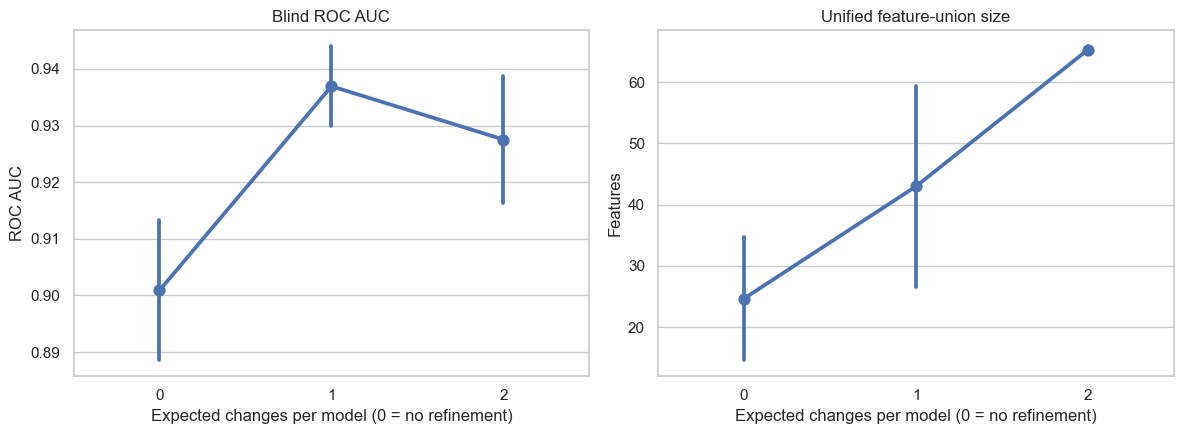

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.pointplot(
    data=comparison_rows, x="expected_changes_per_model", y="roc_auc",
    errorbar="sd", ax=axes[0],
)
axes[0].set(
    title="Blind ROC AUC",
    xlabel="Expected changes per model (0 = no refinement)", ylabel="ROC AUC",
)
sns.pointplot(
    data=comparison_rows, x="expected_changes_per_model",
    y="num_unified_features", errorbar="sd", ax=axes[1],
)
axes[1].set(
    title="Unified feature-union size",
    xlabel="Expected changes per model (0 = no refinement)", ylabel="Features",
)
plt.tight_layout()